## import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2

# use new data

In [3]:
modelname = 'varynode'
iepoch=51
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 22222  # for eval plot 
plot_no_episodes = 555
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
node_list = [10, 25, 40]


In [5]:
# res={}

# for food_reward_idx in range(len(food_reward_list)):
# # for food_reward_idx in [1]:
#         res[food_reward_idx]={}

# for inode, node in enumerate(node_list):
    
#     env_param = [0, None, attcost, .25, facost, 0, 0]
#     seed=0
#     thismodel = f'seed_0_{modelname}_{node}'
#     np.random.seed(seed)
#     task = AFR2(spec={'agent': 
#                                         {'lick_cost': env_param[0],
#                                         'food_reward': env_param[1],
#                                         'attention_cost_coeff': env_param[2],
#                                         'attention_cost_temp': env_param[3],
#                                         'penalty_cost': env_param[4],
#                                         'iti_cost': env_param[5],
#                                         'time_in_game_reward': env_param[6]},
#                                 'experiment':{                              'no_signal_nodes':node}})
#     task.food_reward_list = food_reward_list
#     taskbelief = FuncBeliefModel(env=task, rng=1)
#     task.obs_certainity_possible = np.array([.5,.7])

#     # eval
#     model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')
#     print(f'ycstore/{thismodel}_epoch_{iepoch}')
    
#     def eval_wrapper(a):
#         episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                                 num_steps=100000, deterministic=True)
#         return episode

#     with multiprocess.Pool(processes=8) as pool:
#         all_episode_data = pool.map(eval_wrapper, range(no_episodes))
    
#     for episode in all_episode_data:
#         if inode in res[episode['trial_food_reward_idx']]:
#             res[episode['trial_food_reward_idx']][inode].append(episode)
#         else:
#             res[episode['trial_food_reward_idx']][inode]=[episode]

# save_pickle_file('figdata/vary node p.pkl', res)

# use figdata

In [4]:

res=open_pickle_file('figdata/vary node p.pkl')

In [18]:
start_rgb = (0.6, 0.1, 0.5) # low 
end_rgb = (0.0, 0.2, 0.2) # high 
nodecmap = LinearSegmentedColormap.from_list('nodecmap', [start_rgb, end_rgb])

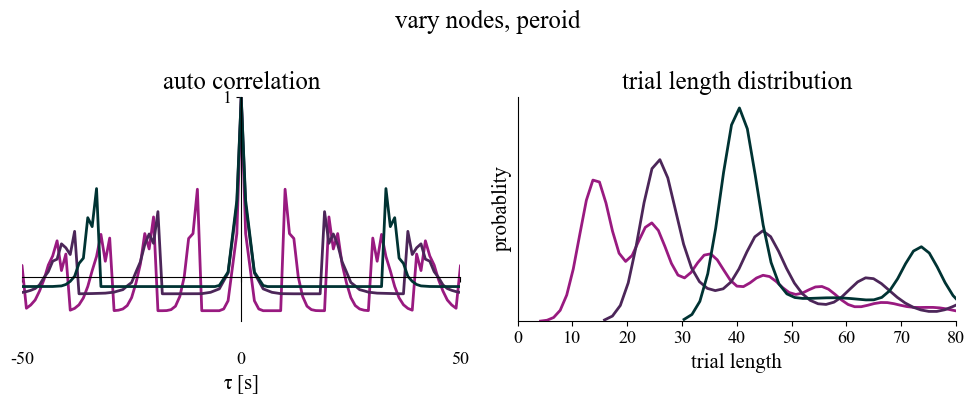

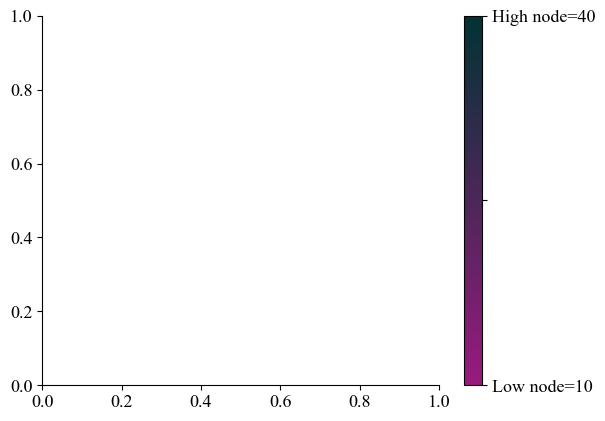

In [26]:
for food_reward_idx in [1]:        
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

    for inode, node in enumerate(node_list):
        all_episode_data=res[food_reward_idx][inode]
        
        att_seq_list = []
        for episode in all_episode_data:
            if episode['trial_food_reward_idx'] == food_reward_idx:
                att_seq_list.append([float(elt[1])
                                    for elt in episode['actions']])
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        # Choosing what range of trial lengths to use. Could modify to be more consistent.
        sequences = sorted_list_of_lists[-plot_no_episodes:]
        # autocorr
        autocorr, total_counts = empirical_autocorrelation_new(
            sequences, min_no_samples=1111)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,
                    label=f'node:{node}', color=nodecmap(np.linspace(0, 1, len(node_list)))[inode])
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2, color=nodecmap(np.linspace(0, 1, len(node_list)))[inode])

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50) 

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_yticks([])
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

    # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
    fig.suptitle(f'vary nodes, peroid')
    plt.tight_layout()
    quicksave('vary node p autocorr', 'plot vary node')
    plt.show()

fig=plt.figure()
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=nodecmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)
quicksave('vary node cmap', 'plot vary node',fig=fig)



(1410, 236)
(1799, 296)
(2220, 310)


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_30541/971099478.py:95: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_30541/971099478.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


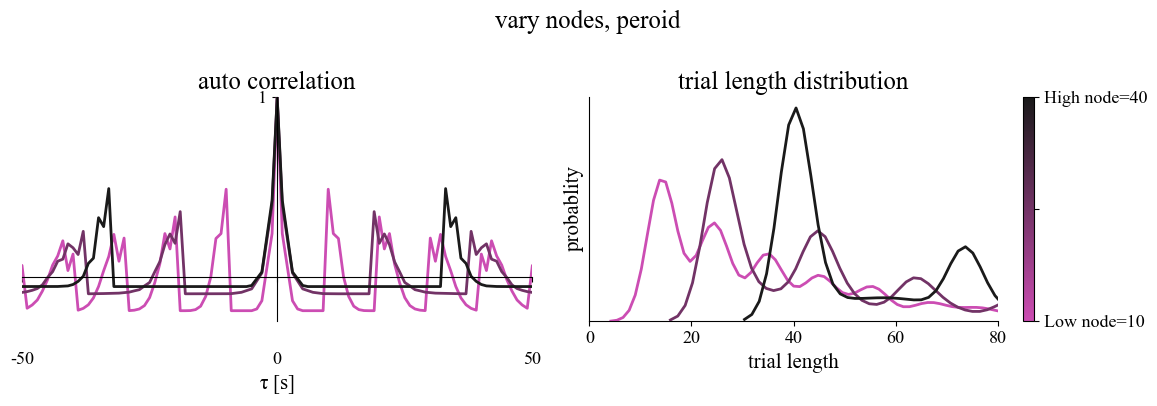

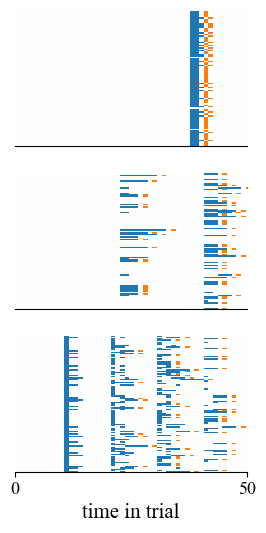

In [41]:
# autocorr with raster
start_rgb = (0.8, 0.3, 0.7) # low node
end_rgb = (0.1, 0.1, 0.1) # high node
cmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])

minlen, maxlen=25,50
for food_reward_idx in [1]:        
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
    rasterfig, axs = plt.subplots(len(node_list), 1, figsize=(
            3, len(node_list)*2,))
    for inode, node in enumerate(node_list):
        all_episode_data=res[food_reward_idx][inode]

        # att times -------------
        all_reward_res={} # k: v = foodreward idx: this food reward res
        for r in range(len(food_reward_list)):
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
            all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len
        for episode in all_episode_data[:]:
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
            att_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
            if episode['actions'][-1][0] == 1:
                lick_time_list.append(len(episode['states']))
            else:
                lick_time_list.append(None)
            trial_len.append(len(episode['actions']))


        # raster fig
        rasterax=axs[len(node_list)-inode-1]
        attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
            food_reward_idx]
        trial_len = np.array(trial_len)
        valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
        grid = np.zeros((len(valid_ind), max(trial_len)+2))
        print(grid.shape)
        sortind = np.argsort([trial_len[i] for i in valid_ind])

        # att
        plot_data = [att_time_list[i] for i in valid_ind]
        for i, arr in enumerate(plot_data):
            arr=arr[1:]
            grid[i, arr] = -1
        # lick
        plot_data = [lick_time_list[i] for i in valid_ind]
        for i, arr in enumerate(plot_data):
            if arr:
                grid[i, arr] = 1

        colors = [attn_color, 'white', lick_color]
        stops = [0.0, 0.5, 1.0]
        attnlickcmap = LinearSegmentedColormap.from_list(
            'custom_cmap', list(zip(stops, colors)))

        c = rasterax.imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                            aspect='auto', interpolation='none')

        rasterax.set_xticks([0, 50])
        rasterax.set_xlim(0, 50)
        rasterax.set_ylim(0,100)
        rasterax.set_yticks([])
        rasterax.set_xticks([])
        rasterax.spines['left'].set_visible(False)

        # auto correlation -------------
        att_seq_list = []
        for episode in all_episode_data:
            if episode['trial_food_reward_idx'] == food_reward_idx:
                att_seq_list.append([float(elt[1])
                                    for elt in episode['actions']])
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        # Choosing what range of trial lengths to use. Could modify to be more consistent.
        sequences = sorted_list_of_lists[-plot_no_episodes:]
        # autocorr
        autocorr, total_counts = empirical_autocorrelation_new(
            sequences, min_no_samples=1111)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,

                    label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[inode])
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[inode])

    axs[-1].set_xticks([0,50])
    axs[-1].set_xlabel('time in trial')
    # lickdot = Patch(color=lick_color, label='lick')
    # attdot = Patch(color=attn_color, label='attention')
    # extra_legend = plt.legend(
    #     handles=[lickdot, attdot], bbox_to_anchor=(0, 1), frameon=True)
    # ax.add_artist(extra_legend)
    rasterfig.show()


    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50) 

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_yticks([])
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
    ticks = [0, 0.5, 1]
    tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)


    # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
    fig.suptitle(f'vary nodes, peroid')
    fig.tight_layout()
    fig.show()
    


quicksave('autocorr p', 'plot vary node', fig=fig)
rasterfig.savefig('fig/plot vary node/autocorr raster p.svg')


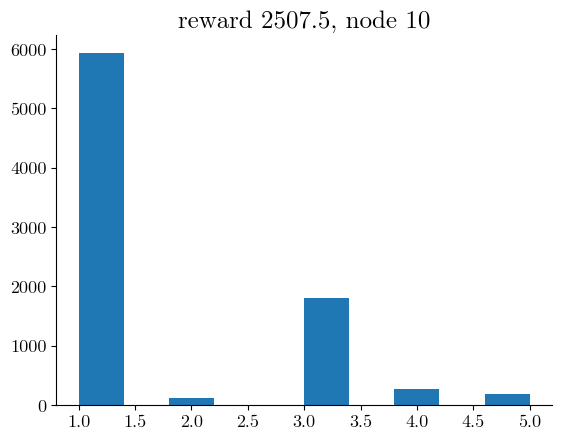

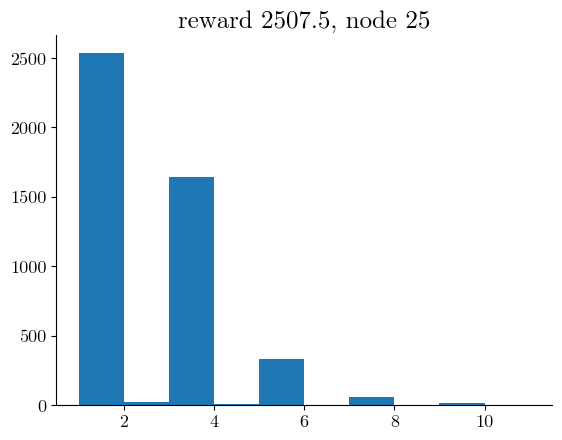

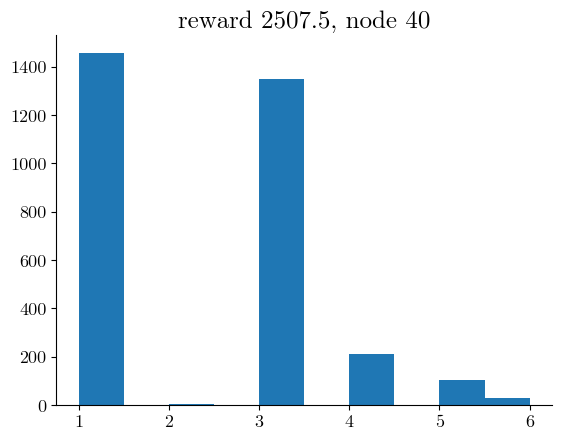

In [ ]:
# continous att block distribution
# find_block_lengths()
for food_reward_idx in [1]:        
    for inode, node in enumerate(node_list):
        all_episode_data=res[food_reward_idx][inode]
        all_reward_res={} # k: v = foodreward idx: this food reward res
        for r in range(len(food_reward_list)):
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
            all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len
        for episode in all_episode_data[:]:
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
            att_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
            if episode['actions'][-1][0] == 1:
                lick_time_list.append(len(episode['states']))
            else:
                lick_time_list.append(None)
            trial_len.append(len(episode['actions']))
        plt.hist(np.concatenate([find_block_lengths(a) for a in att_time_list]))
        plt.title(f'reward {food_reward_list[food_reward_idx]}, node {node_list[inode]}')
        plt.show()
  

# extra

In [ ]:

# modelname = 'varynode'
# iepoch=51
# # training hyper params
# epoch_size = 33333
# n_epoch = 55
# n_seed = 1
# seed = 0
# no_episodes = 3333  # for eval plot during training
# plot_no_episodes = 333
# vmin, vmax = 10, 10000
# food_reward_list = np.linspace(vmin, vmax, 5)
# attcost = -1.6
# facost = -50
# p1p2 = np.array([.5, .7])
# env_param = [0, None, attcost, .25, facost, 0, 0]
# np.random.seed(seed)
# node_list = [10, 25, 40]


# # for food_reward_idx in range(len(food_reward_list)):
# for food_reward_idx in [1]:
#         fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
        
#         # autocorr. 
#         for i, node in enumerate(node_list):
#             env_param = [0, None, attcost, .25, facost, 0, 0]
#             seed=0
#             thismodel = f'seed_0_{modelname}_{node}'
#             np.random.seed(seed)
#             task = AFR2(spec={'agent': 
#                                                 {'lick_cost': env_param[0],
#                                                 'food_reward': env_param[1],
#                                                 'attention_cost_coeff': env_param[2],
#                                                 'attention_cost_temp': env_param[3],
#                                                 'penalty_cost': env_param[4],
#                                                 'iti_cost': env_param[5],
#                                                 'time_in_game_reward': env_param[6]},
#                                         'experiment':{                              'no_signal_nodes':node}})
#             task.food_reward_list = food_reward_list
#             taskbelief = FuncBeliefModel(env=task, rng=1)
#             task.obs_certainity_possible = np.array([.5,.7])
    
#             # eval
#             model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')
#             print(f'ycstore/{thismodel}_epoch_{iepoch}')
            
#             def eval_wrapper(a):
#                 episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                                         num_steps=100000, deterministic=True)
#                 return episode

#             with multiprocess.Pool(processes=8) as pool:
#                 all_episode_data = pool.map(eval_wrapper, range(no_episodes))

#             # auto correlation
#             att_seq_list = []
#             for episode in all_episode_data:
#                 if 

In [ ]:
# episode['trial_food_reward_idx'] == food_reward_idx:
#                     att_seq_list.append([float(elt[1])
#                                         for elt in episode['actions']])
#             # Sorting based on increasing trial length
#             sorted_list_of_lists = sorted(att_seq_list, key=len)
#             # Choosing what range of trial lengths to use. Could modify to be more consistent.
#             sequences = sorted_list_of_lists[-plot_no_episodes:]
#             # autocorr
#             autocorr, total_counts = empirical_autocorrelation(
#                 sequences, min_no_samples=1111)
#             xs = np.arange(0, len(autocorr), 1)
#             xs = xs-len(xs)//2
#             ax1.plot(xs, autocorr,
#                         label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[i])
#             # trial len dist
#             sns.kdeplot([len(a) for a in att_seq_list],
#                         fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[i])

#         ax1.set_xlabel(r'$\tau$ [s]')
#         ax1.set_title('auto correlation')
#         ax1.set_xlim(-50,50)
#         ax1.set_xticks([-50, 0, 50])
#         ax1.set_yscale('log')
#         ax1.set_yticks([])
#         ax1.spines['left'].set_position('zero')

#         ax2.set_xlabel('trial length')
#         ax2.set_ylabel('probablity')
#         ax2.set_yticks([])
#         ax2.set_xlim(0, 80)
#         ax2.set_title('trial length distribution')

#         color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
#         ticks = [0, 0.5, 1]
#         tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
#         color_bar.set_ticks(ticks)
#         color_bar.set_ticklabels(tick_labels)


#         # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
#         fig.suptitle(f'vary nodes, peroid')
#         plt.tight_layout()
#         plt.show()

In [ ]:
# from ult import empirical_autocorrelation_new
# modelname = 'varynode'
# iepoch=51
# # training hyper params
# epoch_size = 33333
# n_epoch = 55
# n_seed = 1
# seed = 0
# no_episodes = 9999  # for eval plot during training
# plot_no_episodes = 333
# vmin, vmax = 10, 10000
# food_reward_list = np.linspace(vmin, vmax, 5)
# attcost = -1.6
# facost = -50
# p1p2 = np.array([.5, .7])
# env_param = [0, None, attcost, .25, facost, 0, 0]
# np.random.seed(seed)
# node_list = [10, 25, 40]


# # for food_reward_idx in range(len(food_reward_list)):
# for food_reward_idx in [1]:
#         fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
        
#         # autocorr. 
#         for i, node in enumerate(node_list):
#             env_param = [0, None, attcost, .25, facost, 0, 0]
#             seed=0
#             thismodel = f'seed_0_{modelname}_{node}'
#             np.random.seed(seed)
#             task = AFR2(spec={'agent': 
#                                                 {'lick_cost': env_param[0],
#                                                 'food_reward': env_param[1],
#                                                 'attention_cost_coeff': env_param[2],
#                                                 'attention_cost_temp': env_param[3],
#                                                 'penalty_cost': env_param[4],
#                                                 'iti_cost': env_param[5],
#                                                 'time_in_game_reward': env_param[6]},
#                                         'experiment':{                              'no_signal_nodes':node}})
#             task.food_reward_list = food_reward_list
#             taskbelief = FuncBeliefModel(env=task, rng=1)
#             task.obs_certainity_possible = np.array([.5,.7])
    
#             # eval
#             model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')
#             print(f'ycstore/{thismodel}_epoch_{iepoch}')
            
#             def eval_wrapper(a):
#                 episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                                         num_steps=100000, deterministic=True)
#                 return episode

#             with multiprocess.Pool(processes=8) as pool:
#                 all_episode_data = pool.map(eval_wrapper, range(no_episodes))

#             # auto correlation
#             att_seq_list = []
#             for episode in all_episode_data:
#                 if episode['trial_food_reward_idx'] == food_reward_idx:
#                     att_seq_list.append([float(elt[1])
#                                         for elt in episode['actions']])
#             # Sorting based on increasing trial length
#             sorted_list_of_lists = sorted(att_seq_list, key=len)
#             # Choosing what range of trial lengths to use. Could modify to be more consistent.
#             sequences = sorted_list_of_lists[-plot_no_episodes:]
#             # autocorr
#             autocorr, total_counts = empirical_autocorrelation_new(
#                 sequences, min_no_samples=1111)
#             xs = np.arange(0, len(autocorr), 1)
#             xs = xs-len(xs)//2
#             ax1.plot(xs, autocorr,
#                         label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[i])
#             # trial len dist
#             sns.kdeplot([len(a) for a in att_seq_list],
#                         fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[i])

#         ax1.set_xlabel(r'$\tau$ [s]')
#         ax1.set_title('auto correlation')
#         ax1.set_xlim(-50, 50)
#         ax1.set_ylim(None, 1)
#         ax1.set_xticks([-50, 0, 50])
#         # ax1.set_yscale('log')
#         ax1.set_yticks([1])
#         ax1.spines['left'].set_position('zero')
#         ax1.spines['bottom'].set_position('zero')
#         ax1.tick_params(axis='x', pad=50) 

#         ax2.set_xlabel('trial length')
#         ax2.set_ylabel('probablity')
#         ax2.set_yticks([])
#         ax2.set_xlim(0, 80)
#         ax2.set_title('trial length distribution')

#         color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
#         ticks = [0, 0.5, 1]
#         tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
#         color_bar.set_ticks(ticks)
#         color_bar.set_ticklabels(tick_labels)


#         # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
#         fig.suptitle(f'vary nodes, peroid')
#         plt.tight_layout()
#         plt.show()

In [ ]:


# modelname = 'varynode'
# iepoch=51
# # training hyper params
# epoch_size = 33333
# n_epoch = 55
# n_seed = 1
# seed = 0
# no_episodes = 999  # for eval plot during training
# plot_no_episodes =999
# vmin, vmax = 10, 10000
# food_reward_list = np.linspace(vmin, vmax, 5)
# attcost = -1.6
# facost = -50
# p1p2 = np.array([.5, .7])
# env_param = [0, None, attcost, .25, facost, 0, 0]
# np.random.seed(seed)
# node_list = [10, 25, 40]
# minlen, maxlen = 50, 100

# # for food_reward_idx in range(len(food_reward_list)):
# for food_reward_idx in [1]:
#     fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
#     rasterfig, axs = plt.subplots(len(node_list), 1, figsize=(
#             2, len(node_list)*4,), sharex=True, sharey=True)
    
#     for nodei, node in enumerate(node_list):
#         env_param = [0, None, attcost, .25, facost, 0, 0]
#         seed=0
#         thismodel = f'seed_0_{modelname}_{node}'
#         np.random.seed(seed)
#         task = AFR2(spec={'agent': 
#                                             {'lick_cost': env_param[0],
#                                             'food_reward': env_param[1],
#                                             'attention_cost_coeff': env_param[2],
#                                             'attention_cost_temp': env_param[3],
#                                             'penalty_cost': env_param[4],
#                                             'iti_cost': env_param[5],
#                                             'time_in_game_reward': env_param[6]},
#                                     'experiment':{                              'no_signal_nodes':node}})
#         task.food_reward_list = food_reward_list
#         taskbelief = FuncBeliefModel(env=task, rng=1)
#         task.obs_certainity_possible = np.array([.5,.7])

#         # eval
#         model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')
#         print(f'ycstore/{thismodel}_epoch_{iepoch}')
        
#         def eval_wrapper(a):
#             episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                                     num_steps=100000, deterministic=True)
#             return episode

#         with multiprocess.Pool(processes=8) as pool:
#             all_episode_data = pool.map(eval_wrapper, range(no_episodes))

#         # att times -------------
#         all_reward_res={} # k: v = foodreward idx: this food reward res
#         for r in range(len(food_reward_list)):
#             attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
#             all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len
#         for episode in all_episode_data[:]:
#             attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
#             att_time_list.append(
#                 np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
#             if episode['actions'][-1][0] == 1:
#                 lick_time_list.append(len(episode['states']))
#             else:
#                 lick_time_list.append(None)
#             trial_len.append(len(episode['actions']))

#         attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
#             food_reward_idx]
#         trial_len = np.array(trial_len)
#         valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
#         grid = np.zeros((len(valid_ind), max(trial_len)+2))
#         sortind = np.argsort([trial_len[i] for i in valid_ind])

#         # att
#         plot_data = [att_time_list[i] for i in valid_ind]
#         for i, arr in enumerate(plot_data):
#             grid[i, arr] = -1
#         # lick
#         plot_data = [lick_time_list[i] for i in valid_ind]
#         for i, arr in enumerate(plot_data):
#             if arr:
#                 grid[i, arr] = 1

#         colors = [attn_color, 'white', lick_color]
#         stops = [0.0, 0.5, 1.0]
#         attnlickcmap = LinearSegmentedColormap.from_list(
#             'custom_cmap', list(zip(stops, colors)))

#         c = axs[nodei].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
#                             aspect='auto', interpolation='none')

#         plt.xticks([0, 50, 100])
#         plt.xlim(0, 100)
#         plt.yticks([])
#         ax = axs[nodei]
#         ax.spines['left'].set_visible(False)

#         # auto correlation -------------
#         att_seq_list = []
#         for episode in all_episode_data:
#             if episode['trial_food_reward_idx'] == food_reward_idx:
#                 att_seq_list.append([float(elt[1])
#                                     for elt in episode['actions']])
#         # Sorting based on increasing trial length
#         sorted_list_of_lists = sorted(att_seq_list, key=len)
#         # Choosing what range of trial lengths to use. Could modify to be more consistent.
#         sequences = sorted_list_of_lists[-plot_no_episodes:]
#         # autocorr
#         autocorr, total_counts = empirical_autocorrelation_new(
#             sequences, min_no_samples=1111)
#         xs = np.arange(0, len(autocorr), 1)
#         xs = xs-len(xs)//2
#         ax1.plot(xs, autocorr,
#                     label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[nodei])
#         # trial len dist
#         sns.kdeplot([len(a) for a in att_seq_list],
#                     fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[nodei])


#     plt.xlabel('time in trial')
#     lickdot = Patch(color=lick_color, label='lick')
#     attdot = Patch(color=attn_color, label='attention')
#     extra_legend = plt.legend(
#         handles=[lickdot, attdot], bbox_to_anchor=(0, 1), frameon=True)
#     ax.add_artist(extra_legend)
#     rasterfig.show()


#     ax1.set_xlabel(r'$\tau$ [s]')
#     ax1.set_title('auto correlation')
#     ax1.set_xlim(-50, 50)
#     ax1.set_ylim(None, 1)
#     ax1.set_xticks([-50, 0, 50])
#     # ax1.set_yscale('log')
#     ax1.set_yticks([1])
#     ax1.spines['left'].set_position('zero')
#     ax1.spines['bottom'].set_position('zero')
#     ax1.tick_params(axis='x', pad=50) 

#     ax2.set_xlabel('trial length')
#     ax2.set_ylabel('probablity')
#     ax2.set_yticks([])
#     ax2.set_xlim(0, 80)
#     ax2.set_title('trial length distribution')

#     # color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
#     # ticks = [0, 0.5, 1]
#     # tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
#     # color_bar.set_ticks(ticks)
#     # color_bar.set_ticklabels(tick_labels)


#     # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
#     fig.suptitle(f'vary nodes, peroid')
#     plt.tight_layout()
#     fig.show()
    

